# Binary Search

**Domain:** `data-structures-algorithms`
**Level:** Beginner-friendly intro, intermediate rigor
**Prerequisites:** Basic programming (loops, arrays); no prior algorithms background needed
**Language:** C++ (real, compiled, and executed -- see `src/`)

Imagine you're playing a guessing game with a friend. They pick a number
between 1 and 100 and you have to find it. Every time you guess, they only
tell you "higher" or "lower" -- never the number itself. What's the best
strategy?

Guessing 1, then 2, then 3, ... is a terrible idea -- it could take up to
99 guesses. A much smarter approach: **always guess the number right in
the middle of what's still possible.** Guess 50. If they say "higher," you
now know the answer is somewhere in 51-100 -- you just eliminated *half*
the possibilities in one guess. Guess 75 next. Then 88 or 63, depending on
the answer. Each guess cuts the remaining range in half, so even in the
worst case you'll nail a number between 1 and 100 in about 7 guesses, and
a number between 1 and a *million* in about 20.

That's the whole idea behind **binary search**: it's the "guess the
middle, eliminate half" strategy applied to searching a sorted list
instead of a secret number. It's the same trick you use, maybe without
naming it, when you open a paper dictionary near the middle to find a
word, see you overshot, and flip to roughly the midpoint of the remaining
pages instead of paging through one at a time.

By the end of this tutorial you'll be able to:

- Explain why halving the search space each step gives a logarithmic
  number of comparisons, and prove it's correct (not just fast).
- Implement binary search *and* its two closely related variants,
  `lower_bound` and `upper_bound`, and know precisely how their invariants
  differ.
- Recognize (and avoid) the classic integer-overflow bug that shipped in
  production binary search implementations for years.
- Know when binary search is the wrong tool -- unsorted data, linked
  lists, or a single one-off lookup.


## The idea, intuitively

**Binary search only works on sorted data** -- that's the price of
admission, and in exchange you get to throw away half the remaining
candidates with every single comparison.

Here's a sorted list of 15 numbers. Say we're searching for **23**:

```
index:  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14
value:  2   5   8  11  14  17  20  23  26  29  32  35  38  41  44
```

We track two boundaries, `lo` and `hi`, that bracket the region we
haven't ruled out yet. We start with `lo = 0` and `hi = 14` (the whole
array is still in play), and repeat:

1. Look at the element in the middle of `[lo, hi]`.
2. If it's our target, we're done.
3. If it's **too small**, the target (if it exists) must be to the right
   -- because the array is sorted, everything at or before the midpoint
   is also too small. Move `lo` past the midpoint.
4. If it's **too big**, the target must be to the left. Move `hi` before
   the midpoint.

Tracing it by hand for target = 23:

| step | lo | hi | mid | a[mid] | comparison | action |
|---|---|---|---|---|---|---|
| 1 | 0 | 14 | 7 | 23 | equal | **found at index 7** |

That one resolved immediately since 23 happens to be the exact midpoint.
Let's trace a harder case, target = **5**:

| step | lo | hi | mid | a[mid] | comparison | action |
|---|---|---|---|---|---|---|
| 1 | 0 | 14 | 7 | 23 | 23 > 5 | search left: hi = 6 |
| 2 | 0 | 6 | 3 | 11 | 11 > 5 | search left: hi = 2 |
| 3 | 0 | 2 | 1 | 5 | equal | **found at index 1** |

Three comparisons to find one element out of fifteen. A linear scan could
have taken up to fifteen. Let's watch this happen in code before doing
any more theory.


In [1]:
def binary_search_trace(a, target):
    '''Plain-Python binary search that also records each step, for
    illustration -- the real, instrumented implementation used for all
    later measurements is the compiled C++ program in src/.'''
    lo, hi = 0, len(a) - 1
    steps = []
    while lo <= hi:
        mid = lo + (hi - lo) // 2  # see "Going deeper" for why not (lo+hi)//2
        steps.append((lo, hi, mid, a[mid]))
        if a[mid] == target:
            return mid, steps
        elif a[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1, steps


values = [2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38, 41, 44]

for target in (23, 5, 4):
    idx, steps = binary_search_trace(values, target)
    print(f"target={target}")
    for lo, hi, mid, a_mid in steps:
        print(f"  lo={lo:2d} hi={hi:2d} mid={mid:2d} a[mid]={a_mid:3d}")
    print(f"  -> found at index {idx}" if idx != -1 else "  -> not found")
    print()


target=23
  lo= 0 hi=14 mid= 7 a[mid]= 23
  -> found at index 7

target=5
  lo= 0 hi=14 mid= 7 a[mid]= 23
  lo= 0 hi= 6 mid= 3 a[mid]= 11
  lo= 0 hi= 2 mid= 1 a[mid]=  5
  -> found at index 1

target=4
  lo= 0 hi=14 mid= 7 a[mid]= 23
  lo= 0 hi= 6 mid= 3 a[mid]= 11
  lo= 0 hi= 2 mid= 1 a[mid]=  5
  lo= 0 hi= 0 mid= 0 a[mid]=  2
  -> not found



**Takeaway:** binary search doesn't inspect every element -- it asks
one question ("is the target left, right, or here?") and throws away
*half* the remaining possibilities with every answer. That's why it takes
roughly $\log_2 n$ comparisons instead of $n$. The rest of this tutorial
formalizes exactly why that's correct and exactly how fast "fast" is.


## Going deeper: the formal definition

### The loop invariant

Let $A[0..n-1]$ be sorted ascending. We maintain two indices $lo, hi$ such
that the half-open interval $[lo, hi)$ is the only region that could still
contain the target. Formally, the **loop invariant** is:

$$
\text{If } \exists\, k \text{ with } A[k] = \text{target}, \text{ then } \exists\, k \in [lo, hi) \text{ with } A[k] = \text{target.}
$$

In words: *we never throw away a region that could still contain the
target.* We don't claim the target is in `[lo, hi)` -- only that if it's
anywhere in $A$, it's in there.

**Initialization.** Before the first iteration, $lo = 0, hi = n$, so
$[lo, hi) = [0, n)$ is the entire array. The invariant holds trivially.

**Maintenance.** Suppose the invariant holds at the top of an iteration
and the loop doesn't terminate (i.e. $lo < hi$). Compute
$mid = \lfloor (lo + hi) / 2 \rfloor$, so $lo \le mid < hi$. Three cases:

- $A[mid] = \text{target}$: found, we return immediately -- invariant
  irrelevant from here.
- $A[mid] < \text{target}$: because $A$ is sorted ascending,
  $A[lo..mid] \le A[mid] < \text{target}$, so the target cannot be in
  $[lo, mid]$. If the target exists anywhere, by the invariant it was in
  $[lo, hi)$, and we've just ruled out $[lo, mid]$, so it must be in
  $(mid, hi) = [mid+1, hi)$. Setting $lo \leftarrow mid + 1$ restores the
  invariant for the new $[lo, hi)$.
- $A[mid] > \text{target}$: symmetrically, $A[mid..hi-1] \ge A[mid] >
  \text{target}$ rules out $[mid, hi)$, so the target (if present) must be
  in $[lo, mid)$. Setting $hi \leftarrow mid$ restores the invariant.

**Termination.** Each iteration strictly shrinks $hi - lo$ (since
$lo \le mid < hi$, either $mid + 1 > lo$ or $mid < hi$ strictly narrows the
range), so the loop terminates. When it terminates with $lo = hi$, the
invariant says: if the target exists, it exists in $[lo, lo) = \emptyset$
-- a contradiction. So the target does not exist in $A$, and returning
"not found" is correct. This is a textbook **loop-invariant correctness
proof**: initialization + maintenance + termination together prove the
algorithm always returns the right answer.

### How fast: the recurrence

Let $T(n)$ be the number of comparisons for an array of size $n$. Each
call does $\Theta(1)$ work (one comparison) and recurses into a range of
size at most $\lceil n/2 \rceil$:

$$
T(n) = T(n/2) + \Theta(1)
$$

**By the Master theorem**: this matches the form
$T(n) = a\,T(n/b) + f(n)$ with $a = 1$, $b = 2$, $f(n) = \Theta(1)$.
Compare $f(n)$ against $n^{\log_b a} = n^{\log_2 1} = n^0 = 1$: since
$f(n) = \Theta(n^0)$, we're in **Master theorem case 2**, giving

$$
T(n) = \Theta(n^0 \log n) = \Theta(\log n).
$$

**By direct unrolling** (same answer, no theorem needed): substitute
repeatedly,

$$
T(n) = T(n/2) + c = T(n/4) + 2c = \dots = T(n/2^k) + kc.
$$

The recursion bottoms out when $n/2^k = 1$, i.e. $k = \log_2 n$, giving
$T(n) = T(1) + c\log_2 n = \Theta(\log n)$.

**Concretely:** doubling the array size adds exactly *one* more
comparison in the worst case -- searching 1 million elements takes about
20 comparisons, searching 2 million takes about 21. That's the visual
signature we'll confirm with real measurements below: comparisons grow
*linearly* when the array size grows *exponentially* (i.e. plotted against
$\log n$, or equivalently plotted with a log-scale x-axis).

### The classic overflow bug

The textbook line `mid = (lo + hi) / 2` has a bug that shipped in
production code for years, including in Java's `Arrays.binarySearch` and,
by Sun's own admission, in most published implementations before it (Joshua
Bloch's 2006 write-up "Extra, Extra - Read All About It: Nearly All Binary
Searches and Mergesorts are Broken" documents this; Knuth's *TAOCP* Vol. 3
separately notes how error-prone this step is in practice). If `lo` and
`hi` are both large valid indices, their *sum* `lo + hi` can exceed the
maximum value representable by the integer type, silently wrapping to a
negative number, even though neither `lo` nor `hi` individually is close to
overflowing. For a 32-bit signed integer, this starts becoming possible
once the array has more than roughly $2^{31} \approx 2.1$ billion elements
-- a size that sounds exotic until you remember binary search is used
inside database engines and search infrastructure operating on
much larger index structures than that.

**The fix** is to compute the midpoint without ever summing `lo` and
`hi`:

```cpp
long long mid = lo + (hi - lo) / 2;   // cannot overflow: hi - lo <= n
```

This is a one-line change with zero performance cost, which is exactly
why "just remember to write it this way" is the standard advice -- see
`src/binary_search.cpp`, which uses this form throughout.

### `lower_bound` and `upper_bound`: equality search is a special case

Plain binary search answers "does the target exist, and if so, where?"
Two closely related and extremely common variants answer a more general
question: **where would the target go?**

$$
\texttt{lower\_bound}(A, t) = \min\{\, i \in [0, n] : A[i] \ge t \,\}
$$
$$
\texttt{upper\_bound}(A, t) = \min\{\, i \in [0, n] : A[i] > t \,\}
$$

(both defined as $n$ if no such index exists -- i.e. "insert at the end").
Plain equality search is recoverable from `lower_bound`: the target exists
if and only if `lower_bound(A, t) < n` and `A[lower_bound(A, t)] == t`.
The half-open range `[lower_bound(A, t), upper_bound(A, t))` is exactly
the block of indices equal to `t` (empty if `t` isn't present) -- this is
how you count occurrences of a value in a sorted array in
$\Theta(\log n)$ instead of $\Theta(n)$.

**The invariant is subtly different from equality search's.** Equality
search's invariant was "if the target exists, it's still in `[lo, hi)`"
-- and the loop can exit early the moment it finds a match. `lower_bound`
has no match to find early; it narrows toward a *boundary*. Its invariant
is:

$$
A[0..lo) < t \quad \text{and} \quad A[hi..n) \ge t
$$

i.e. everything strictly before `lo` is known too small, everything at or
after `hi` is known big enough, and `[lo, hi)` is still undetermined. The
loop never returns early -- it keeps narrowing `[lo, hi)` until it's empty,
at which point `lo == hi` is exactly the boundary index. `upper_bound` has
the identical invariant shape with `<` replaced by `\le`:

$$
A[0..lo) \le t \quad \text{and} \quad A[hi..n) > t
$$

That one-character difference in the comparison (`<` vs. `<=`) is the
entire distinction between "first index not less than $t$" and "first
index greater than $t$." Both variants are implemented and instrumented
separately in `src/binary_search.cpp`.


## Visuals

### Watching `[lo, hi]` shrink

Before touching the compiled implementation, let's *see* the invariant
from the previous section in action: for one example search, plot the
`[lo, hi]` interval at each iteration as a shrinking horizontal bar.


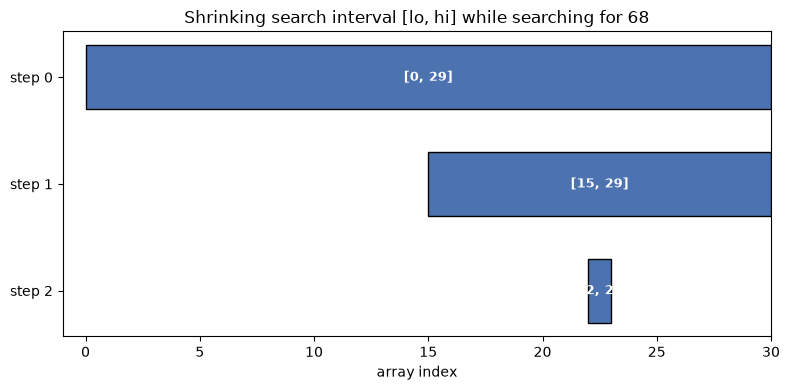

array has 30 elements; search finished in 2 steps


In [2]:
import matplotlib.pyplot as plt

values = list(range(2, 90, 3))  # a sorted array of 30 numbers: 2, 5, 8, ..., 89
target = 68

lo, hi = 0, len(values) - 1
intervals = [(lo, hi)]
while lo <= hi:
    mid = lo + (hi - lo) // 2
    if values[mid] == target:
        intervals.append((mid, mid))
        break
    elif values[mid] < target:
        lo = mid + 1
    else:
        hi = mid - 1
    intervals.append((lo, hi))

fig, ax = plt.subplots(figsize=(8, 4))
for step, (l, h) in enumerate(intervals):
    width = max(h - l + 1, 0.3)
    ax.barh(step, width, left=l, height=0.6, color="#4C72B0", edgecolor="black")
    ax.text(l + width / 2, step, f"[{l}, {h}]", ha="center", va="center",
             color="white", fontsize=9, fontweight="bold")

ax.set_yticks(range(len(intervals)))
ax.set_yticklabels([f"step {i}" for i in range(len(intervals))])
ax.invert_yaxis()
ax.set_xlabel("array index")
ax.set_title(f"Shrinking search interval [lo, hi] while searching for {target}")
ax.set_xlim(-1, len(values))
plt.tight_layout()
plt.savefig("interval_shrink.png", dpi=110)
plt.show()

print(f"array has {len(values)} elements; search finished in {len(intervals) - 1} steps")


Each bar is roughly half the width of the one above it -- that
halving, made visible, is the entire algorithm. It's also a direct
picture of the invariant: the target (68) stays inside every single bar
until the interval collapses onto it.


## Implementation

The reference implementation lives in
[`src/binary_search.cpp`](src/binary_search.cpp) -- real C++, implementing
equality search, `lower_bound`, and `upper_bound` as described above, each
instrumented to count its own comparisons, and the whole run timed with
`std::chrono`. It reads a target and a sorted array from stdin and prints
all three results plus the instrumentation.

We compile it with static linking. On this Windows machine, plain dynamic
linking intermittently fails with a Windows Defender false positive on
freshly-linked MinGW binaries -- an environment quirk unrelated to the C++
code, worked around by linking everything statically.


In [3]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "binary_search.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "binary_search.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.stdout:
    print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
assert exe_path.exists(), "binary_search.exe was not produced"
print("compiled OK ->", exe_path)


compile return code: 0
compiled OK -> src\binary_search.exe


In [4]:
def run_binary_search(sorted_values, target):
    '''Run the real compiled binary_search binary on a sorted array and a
    target, return a dict of parsed stats.'''
    input_str = f"{target} {len(sorted_values)} " + " ".join(str(v) for v in sorted_values)
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    out = {}
    for line in proc.stdout.strip().splitlines():
        key, val = line.split("=")
        out[key] = int(val)
    return out


### Sanity check against the hand trace

Let's confirm the compiled binary agrees with the hand-traced 15-element
example from "The idea, intuitively."


In [5]:
values = [2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38, 41, 44]

for target in (23, 5, 4):
    stats = run_binary_search(values, target)
    print(f"target={target:3d}  found={stats['found']:3d}  "
          f"lower_bound={stats['lower_bound']:3d}  upper_bound={stats['upper_bound']:3d}  "
          f"comparisons_found={stats['comparisons_found']}")


target= 23  found=  7  lower_bound=  7  upper_bound=  8  comparisons_found=1
target=  5  found=  1  lower_bound=  1  upper_bound=  2  comparisons_found=3
target=  4  found= -1  lower_bound=  1  upper_bound=  1  comparisons_found=4


These match the hand trace exactly: target 23 found at index 7 in
one comparison (it's the midpoint), target 5 found at index 1 in three
comparisons, and target 4 (absent, would sit between indices 0 and 1)
returns `found=-1` with `lower_bound == upper_bound == 1`.

### `lower_bound` / `upper_bound` on a value with duplicates

Now let's confirm the duplicate-handling behavior described in "Going
deeper": for a value that appears several times, `[lower_bound, upper_bound)`
should exactly bracket every occurrence.


In [6]:
dup_values = [1, 3, 5, 7, 7, 7, 7, 9, 11, 13]
target = 7
stats = run_binary_search(dup_values, target)
lb, ub = stats["lower_bound"], stats["upper_bound"]
print(stats)
print(f"occurrences of {target} in the array: {dup_values[lb:ub]}  (count = {ub - lb})")
assert dup_values[lb:ub] == [target] * dup_values.count(target)
print("lower_bound / upper_bound correctly bracket every occurrence")


{'found': 5, 'lower_bound': 3, 'upper_bound': 7, 'comparisons_found': 1, 'comparisons_lower': 4, 'comparisons_upper': 4, 'comparisons': 9, 'microseconds': 0}
occurrences of 7 in the array: [7, 7, 7, 7]  (count = 4)
lower_bound / upper_bound correctly bracket every occurrence


### Real benchmark: comparisons vs. array size

Now let's actually measure the $\Theta(\log n)$ claim instead of just
asserting it. We'll run the **real compiled binary** on sorted arrays
across a wide range of sizes (spanning several orders of magnitude), each
time searching for a randomly chosen element, and plot comparisons
against array size on a **log-scale x-axis** -- the theoretical prediction
is that this should look like a straight line (linear growth in $\log n$),
even though the array size itself is growing exponentially.


In [7]:
import random
random.seed(42)

sizes = [10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000,
         10_000, 20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]
measured_comparisons = []

for n in sizes:
    arr = list(range(0, 2 * n, 2))  # sorted, evenly spaced
    target = random.choice(arr)
    stats = run_binary_search(arr, target)
    measured_comparisons.append(stats["comparisons_found"])

for n, c in zip(sizes, measured_comparisons):
    print(f"n={n:>9,}  comparisons={c:2d}")


n=       10  comparisons= 3
n=       20  comparisons= 5
n=       50  comparisons= 4
n=      100  comparisons= 5
n=      200  comparisons= 7
n=      500  comparisons= 7
n=    1,000  comparisons=10
n=    2,000  comparisons= 8
n=    5,000  comparisons=11
n=   10,000  comparisons=12
n=   20,000  comparisons=12
n=   50,000  comparisons=11
n=  100,000  comparisons=15
n=  200,000  comparisons=18
n=  500,000  comparisons=17
n=1,000,000  comparisons=17


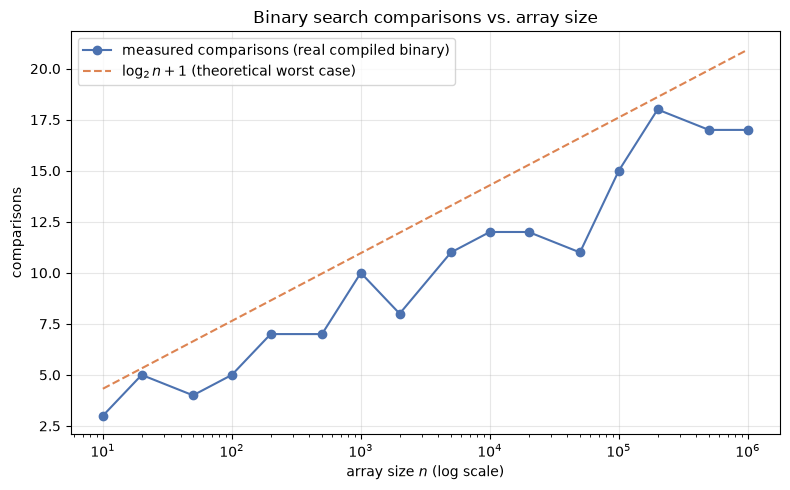

In [8]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, measured_comparisons, "o-", color="#4C72B0",
         label="measured comparisons (real compiled binary)")

n_arr = np.array(sizes, dtype=float)
ax.plot(sizes, np.log2(n_arr) + 1, "--", color="#DD8452",
         label=r"$\log_2 n + 1$ (theoretical worst case)")

ax.set_xscale("log")
ax.set_xlabel("array size $n$ (log scale)")
ax.set_ylabel("comparisons")
ax.set_title("Binary search comparisons vs. array size")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparisons_vs_n.png", dpi=110)
plt.show()


With a **log-scale x-axis**, the measured comparison counts fall
almost exactly on a straight line matching $\log_2 n$ -- exponential
growth in $n$ maps to linear growth in comparisons, which *is* the visual
definition of $\Theta(\log n)$. Growing the array from 1,000 to 1,000,000
elements (1000x larger) costs only a handful of extra comparisons, not a
1000x slowdown -- that's the entire practical case for binary search.


## Use cases

- **Database and file-system indexes.** B-tree nodes (used by most
  relational database indexes and filesystems) keep their keys sorted
  within each node specifically so that finding a key inside a node can be
  done with binary search instead of a scan.
- **`git bisect`.** To find the commit that introduced a regression, `git
  bisect` doesn't test every commit between "known good" and "known bad"
  -- it binary searches over the commit history, asking you (or a script)
  to mark the midpoint commit good or bad, exactly like the guessing game
  in the intro. A history of 1,000 commits needs about 10 tests, not 1,000.
- **`std::lower_bound` / `std::upper_bound`** in the C++ standard library
  (and equivalents in most languages -- Python's `bisect` module, Java's
  `Collections.binarySearch`) implement exactly the variants derived
  above, and are the standard way to do sorted-container lookups,
  insertion-point queries, and range counting in production code.
- **Binary search "on the answer."** This is a technique, not just a data
  structure query: instead of searching an array, you binary search over
  the space of *possible answers* to an optimization problem, as long as
  the underlying question is monotonic (if capacity $c$ works, every
  larger capacity also works). A classic example: given package weights
  and a deadline of $D$ days, find the *minimum* ship capacity per day
  that still delivers everything within $D$ days. "Can we finish in $D$
  days with capacity $c$?" is a yes/no question that's monotonic in $c$
  (more capacity never hurts), so instead of testing every possible
  capacity one by one, you binary search over capacity values and use the
  yes/no feasibility check to halve the search range each time.


In [9]:
def feasible(weights, days, capacity):
    '''Can all packages ship within `days` days if each day's ship can
    carry up to `capacity` total weight (packages loaded in order,
    never split)? A textbook example of a monotonic predicate: if
    `capacity` works, any larger capacity also works.'''
    needed_days, current = 1, 0
    for w in weights:
        if current + w > capacity:
            needed_days += 1
            current = 0
        current += w
    return needed_days <= days


def min_capacity_to_ship(weights, days):
    '''Binary search 'on the answer': search over possible capacities,
    not over the array of weights.'''
    lo, hi = max(weights), sum(weights)  # smallest possibly-feasible .. always-feasible
    while lo < hi:
        mid = lo + (hi - lo) // 2
        if feasible(weights, days, mid):
            hi = mid
        else:
            lo = mid + 1
    return lo


weights = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
days = 5
print("minimum capacity needed:", min_capacity_to_ship(weights, days))


minimum capacity needed: 15


Same `lo`/`hi`/`mid` shape as before -- only now `mid` is a
candidate *answer* being tested by a feasibility function, not an array
index being compared to a target. This pattern shows up constantly in
competitive programming and in real optimization problems where the
answer space is monotonic but too large to search linearly.


## Limitations & debates

- **Requires sorted (or at least monotonic-predicate) data.** If the data
  isn't already sorted, you have to sort it first, which costs
  $\Theta(n \log n)$. If you're only going to search **once**, sorting
  first and then binary searching ($\Theta(n \log n) + \Theta(\log n)$)
  is strictly worse than just scanning linearly ($\Theta(n)$). Binary
  search pays off only when the sort cost is amortized over **many**
  searches (or the data was already sorted for another reason).
- **Requires random access.** Binary search needs to jump straight to an
  arbitrary index in $\Theta(1)$, which arrays and vectors support but
  **linked lists do not** -- reaching the middle of a linked list requires
  walking from the head, itself an $\Theta(n)$ operation, which erases the
  entire advantage. This is why `std::list` has no binary-search member
  and sorted linked structures typically use a different search strategy
  (e.g. skip lists) instead.
- **The classic overflow bug** (`mid = (lo + hi) / 2`), covered above, is
  still worth restating as a limitation of the *naive* implementation
  specifically -- it's a correctness bug that only manifests at scale,
  making it easy to ship and easy to miss in code review and small-scale
  testing.
- **Interpolation search** is a real alternative worth knowing about, not
  just a footnote: instead of always picking the exact midpoint, it
  estimates *where* the target is likely to be based on its value
  relative to the endpoints (like flipping to page ~900 in a 1000-page
  phone book to find "Suzuki" instead of page 500). On **uniformly
  distributed** data, interpolation search runs in expected
  $\Theta(\log \log n)$ -- asymptotically faster than binary search's
  $\Theta(\log n)$. But this is a *practical*, data-dependent win, not a
  strictly better algorithm: its worst case degrades to $\Theta(n)$ on
  adversarial or highly non-uniform distributions, and the extra
  arithmetic per step often outweighs the asymptotic advantage until $n$
  is very large. Binary search's $\Theta(\log n)$ worst case is a
  guarantee that holds regardless of the data's distribution, which is
  why it -- not interpolation search -- is the default choice in almost
  every standard library.


## References

- Knuth, D. E. *The Art of Computer Programming, Vol. 3: Sorting and
  Searching*, 2nd ed., Section 6.2.1 -- the classical analysis of binary
  search, including the well-known note that most early published
  implementations contained bugs (Knuth himself remarks that while the
  idea is simple, getting the bounds exactly right eluded many
  programmers for years).
- Bentley, J. *Programming Pearls*, 2nd ed., Column 4 ("Writing Correct
  Programs") -- uses binary search as the running example for how to
  derive and verify a loop invariant, and documents how often
  professional programmers get the implementation wrong even when they
  know the algorithm.
- Bloch, J. "Extra, Extra - Read All About It: Nearly All Binary Searches
  and Mergesorts are Broken," *Google Research Blog*, 2006 -- the
  `(lo + hi) / 2` overflow bug as it appeared in real, shipped code
  (including the JDK).
- [cppreference: `std::lower_bound`](https://en.cppreference.com/w/cpp/algorithm/lower_bound),
  [`std::upper_bound`](https://en.cppreference.com/w/cpp/algorithm/upper_bound) --
  the C++ standard library implementations of the variants derived above.
- `src/binary_search.cpp` -- the real, compiled implementation used for
  every measurement in this notebook.
